In [ ]:
from pathlib import Path
import sys
import numpy as np
from tqdm import tqdm

sys.path.append(str(Path.cwd().parent))
from project_1.data.load_preprocces import (
    load_data,
    one_hot_encoder
)
from project_1.features.feature_extraction import (
    feature_extrac_mel,
    feature_extrac_mfcc,
    file_opener,
    transpose,
    split_feature
)

from project_1.models.train_functions import (
    cross_callbacks,
    save_callbacks,
    model_CNN,
    normalize_and_pad,
    model_MLP,
    visualize_loss_curve,
    get_predictions,
    evaluate_model
)


In [2]:
data_dir = Path.cwd().parent / "data"
data = load_data(data_dir)

fetur_funcs = {"mel": feature_extrac_mel,
               "mfcc": feature_extrac_mfcc}

fetur_DTsets = {"mel": {"X": [], "y": []},
                "mfcc": {"X": [], "y": []}}

In [3]:
for class_label, file_paths in tqdm(data.items()):
    for file_path in file_paths:
        features = file_opener(file_path, fetur_funcs)

        for name, value in features.items():
            fetur_DTsets[name]["X"].append(value)
            fetur_DTsets[name]["y"].append(class_label)


  0%|          | 0/8 [00:00<?, ?it/s]c:\Users\jkid4\.virtualenvs\project_1_folder-MwoIS0fJ\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 8/8 [07:39<00:00, 57.41s/it]


In [ ]:
for name in fetur_DTsets:
    fetur_DTsets[name]["X"] = transpose(fetur_DTsets[name]["X"])
    fetur_DTsets[name]["X"] = normalize_and_pad(fetur_DTsets[name]["X"], name, 87)
    

In [ ]:
fetur_DTsets[name]["X"] = np.array(fetur_DTsets[name]["X"], dtype=np.float32)
fetur_DTsets[name]["y"] = np.array(fetur_DTsets[name]["y"])

In [6]:
X_mel = fetur_DTsets["mel"]["X"]
X_mfcc = fetur_DTsets["mfcc"]["X"]
y_endoded, target_names = one_hot_encoder(fetur_DTsets["mel"]["y"])
name_mf = "Trained_model_mfcc-0.1.0"
name_ml = "Trained_model_mel-0.1.0"

In [7]:
X_train_val, X_test, y_train_val, y_test = split_feature(X_mfcc, y_endoded)

In [8]:
from keras.optimizers import AdamW
from keras.metrics import F1Score
from keras.callbacks import EarlyStopping
import keras

In [9]:
model = model_MLP()

In [10]:
optimize = AdamW()
f1_score = F1Score(average="macro")
stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)


model = model_MLP()
lr = cross_callbacks(1)

model.compile(
    optimizer=optimize,
    loss="categorical_crossentropy",
    metrics=["accuracy", f1_score],
)

save_name = name_mf + ".keras"
path = Path.cwd().parent / "models" / save_name
save = save_callbacks(path)

history = model.fit(
    X_train_val,
    y_train_val,
    epochs=100,
    validation_split=.1,
    callbacks=[stop, save, lr],
)

Epoch 1/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7459 - f1_score: 0.7453 - loss: 0.7430 - val_accuracy: 0.8694 - val_f1_score: 0.8691 - val_loss: 0.3956 - learning_rate: 0.0010
Epoch 2/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8904 - f1_score: 0.8904 - loss: 0.3392 - val_accuracy: 0.8746 - val_f1_score: 0.8753 - val_loss: 0.3802 - learning_rate: 0.0010
Epoch 3/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9152 - f1_score: 0.9152 - loss: 0.2636 - val_accuracy: 0.9051 - val_f1_score: 0.9053 - val_loss: 0.2957 - learning_rate: 0.0010
Epoch 4/100
476/481 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9352 - f1_score: 0.9352 - loss: 0.2040
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
481/481 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9344 - f1_score: 0.9344 - loss: 0.2038 - val_accuracy: 0.8858 - val_f1_score: 0.8873 - val_loss: 0.3665 - learning_rate: 0.0010
Epoch 5/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 7s 

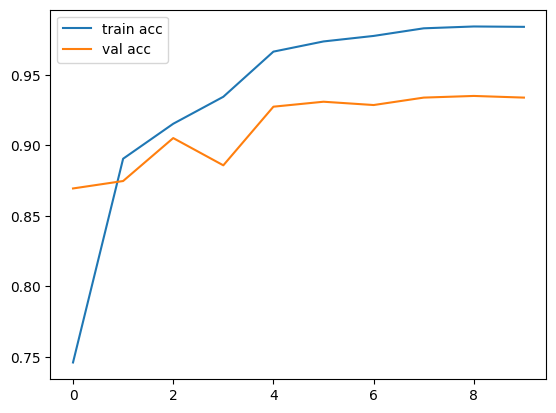

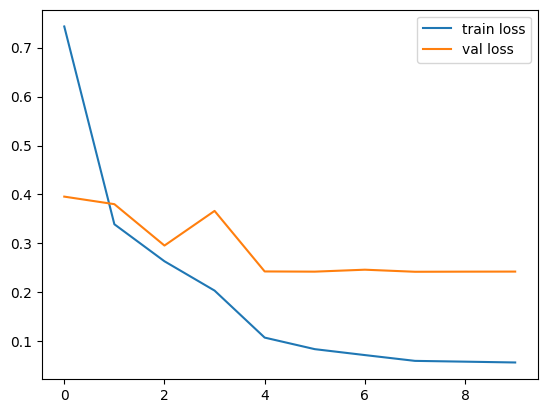

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

          go     0.9212    0.9367    0.9289       237
        left     0.9244    0.9362    0.9302       235
          no     0.9274    0.9156    0.9214       237
          on     0.9106    0.9030    0.9068       237
       right     0.9690    0.9241    0.9460       237
        stop     0.9271    0.9622    0.9443       238
          up     0.9331    0.9370    0.9350       238
         yes     0.9747    0.9706    0.9726       238

    accuracy                         0.9357      1897
   macro avg     0.9359    0.9357    0.9357      1897
weighted avg     0.9360    0.9357    0.9357      1897



In [11]:
visualize_loss_curve(history)
y_pred, test_lables = get_predictions(model, X_test, y_test)
evaluate_model(y_pred, test_lables, target_names)

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_1           │ (None, 87, 30)         │           120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 87, 256)        │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 87, 256)        │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 87, 256)        │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 622,346 (2.37 MB)

 Trainable params: 207,428 (810.27 KB)

 Non-trainable params: 60 (240.00 B)

 Optimizer params: 414,858 (1.58 MB)

In [13]:
keras.backend.clear_session()

In [14]:
X_train_val, X_test, y_train_val, y_test = split_feature(X_mel, y_endoded)


In [15]:
X_train_val = X_train_val[..., np.newaxis]

In [16]:
optimize = AdamW()
f1_score = F1Score(average="macro")
stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

model = model_CNN()
lr = cross_callbacks(1)

model.compile(
    optimizer=optimize,
    loss="categorical_crossentropy",
    metrics=["accuracy", f1_score],
)

save_name = name_ml + ".keras"
path = Path.cwd().parent  / "models" / save_name
save = save_callbacks(path)

history = model.fit(
    X_train_val,
    y_train_val,
    epochs=100,
    validation_split=0.1,
    callbacks=[stop, save, lr],
)


Epoch 1/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 241s 495ms/step - accuracy: 0.4098 - f1_score: 0.3857 - loss: 3.3197 - val_accuracy: 0.5542 - val_f1_score: 0.4925 - val_loss: 2.0994 - learning_rate: 0.0010
Epoch 2/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 242s 504ms/step - accuracy: 0.6866 - f1_score: 0.6862 - loss: 1.2159 - val_accuracy: 0.7873 - val_f1_score: 0.7846 - val_loss: 0.8669 - learning_rate: 0.0010
Epoch 3/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 242s 504ms/step - accuracy: 0.7297 - f1_score: 0.7272 - loss: 0.9165 - val_accuracy: 0.8653 - val_f1_score: 0.8631 - val_loss: 0.6004 - learning_rate: 0.0010
Epoch 4/100
480/481 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.7601 - f1_score: 0.7571 - loss: 0.8219
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
481/481 ━━━━━━━━━━━━━━━━━━━━ 242s 503ms/step - accuracy: 0.7626 - f1_score: 0.7602 - loss: 0.7986 - val_accuracy: 0.7950 - val_f1_score: 0.8033 - val_loss: 0.7132 - learning_rate: 0.0010
Epoch 5/100
481/481 ━━━━━━━━━━━

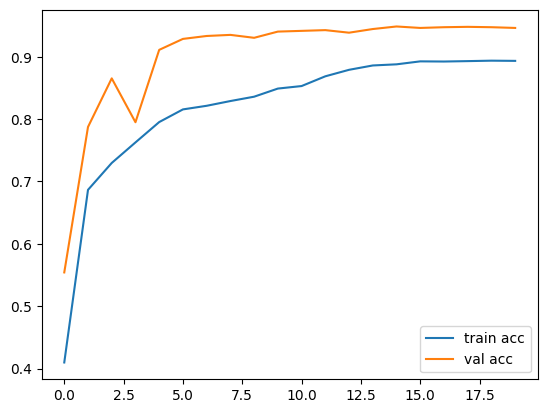

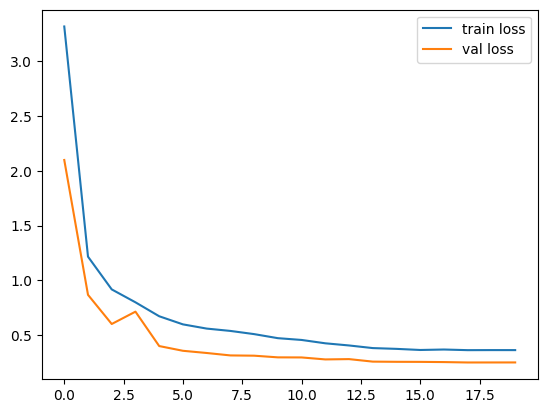

60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step
              precision    recall  f1-score   support

          go     0.9348    0.9072    0.9208       237
        left     0.9463    0.9745    0.9602       235
          no     0.9435    0.9156    0.9293       237
          on     0.9702    0.9620    0.9661       237
       right     0.9784    0.9536    0.9658       237
        stop     0.9474    0.9832    0.9649       238
          up     0.9309    0.9622    0.9463       238
         yes     0.9873    0.9790    0.9831       238

    accuracy                         0.9547      1897
   macro avg     0.9548    0.9547    0.9546      1897
weighted avg     0.9548    0.9547    0.9546      1897



In [17]:
visualize_loss_curve(history)
y_pred, test_lables = get_predictions(model, X_test, y_test)
evaluate_model(y_pred, test_lables, target_names)

In [18]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 87, 128,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 87, 128,   │        512 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 87, 128,   │        704 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 87, 128,   │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 87, 128,   │      1,088 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 43, 64,    │          0 │ conv2d[0][0]      │
│ (AveragePooling2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_2 │ (None, 43, 64,    │          0 │ conv2d_3[0][0]    │
│ (AveragePooling2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_4 │ (None, 43, 64,    │          0 │ conv2d_6[0][0]    │
│ (AveragePooling2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_6 │ (None, 43, 64,    │          0 │ conv2d_9[0][0]    │
│ (AveragePooling2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 43, 64,    │     30,784 │ average_pooling2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 43, 64,    │     43,072 │ average_pooling2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 43, 64,    │     55,360 │ average_pooling2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 43, 64,    │     67,648 │ average_pooling2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_1 │ (None, 21, 32,    │          0 │ conv2d_1[0][0]    │
│ (AveragePooling2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_3 │ (None, 21, 32,    │          0 │ conv2d_4[0][0]    │
│ (AveragePooling2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_5 │ (None, 21, 32,    │          0 │ conv2d_7[0][0]    │
│ (AveragePooling2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_7 │ (None, 21, 32,    │          0 │ conv2d_10[0][0] 

 Total params: 3,015,162 (11.50 MB)

 Trainable params: 1,004,712 (3.83 MB)

 Non-trainable params: 1,024 (4.00 KB)

 Optimizer params: 2,009,426 (7.67 MB)

In [19]:
from tensorflow.keras.models import load_model
path_model = Path.cwd().parent  / "models" / "Trained_model_mel-0.1.0.keras"
test_model_mel = load_model(path_model)

In [20]:
y_pred_test, test_lables_test = get_predictions(test_model_mel, X_test, y_test)
evaluate_model(y_pred_test, test_lables_test, target_names)

60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step
              precision    recall  f1-score   support

          go     0.9348    0.9072    0.9208       237
        left     0.9463    0.9745    0.9602       235
          no     0.9435    0.9156    0.9293       237
          on     0.9702    0.9620    0.9661       237
       right     0.9784    0.9536    0.9658       237
        stop     0.9474    0.9832    0.9649       238
          up     0.9309    0.9622    0.9463       238
         yes     0.9873    0.9790    0.9831       238

    accuracy                         0.9547      1897
   macro avg     0.9548    0.9547    0.9546      1897
weighted avg     0.9548    0.9547    0.9546      1897



In [21]:
path = Path.cwd().parent / "data"
def load_data(path: Path) -> dict[str, list[Path]]:
    d_fold = sorted([f for f in path.iterdir() if f.is_dir()])
    data = {fldr.name: sorted(fldr.glob("*.wav")) for fldr in d_fold}
    return data
test = load_data(path)

In [22]:
import numpy as np
from project_1.data.load_preprocces import one_hot_encoder

# Get the EXACT label order that was used during training
y_sample = ["go", "left", "no", "on", "right", "stop", "up", "yes"]  # simulate
y_endoded, target_names = one_hot_encoder(y_sample)

print("Target names (classes in training order):")
print(target_names)
print("\nOne-hot encoding for each class:")
for i, name in enumerate(target_names):
    print(f"Index {i}: {name}")


Target names (classes in training order):
['go', 'left', 'no', 'on', 'right', 'stop', 'up', 'yes']

One-hot encoding for each class:
Index 0: go
Index 1: left
Index 2: no
Index 3: on
Index 4: right
Index 5: stop
Index 6: up
Index 7: yes
